## 3DoF Entry VTOL w/o Aoa SCP

Imports

In [1]:
# Basic imports
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp as scp
import trajopt.core.problem as prob
import trajopt.utils.config_loader as cfg
import trajopt.utils.tools as tools
import trajopt.analysis.default_analysis as default_analysis
import trajopt.analysis.statistics as stats
import copy

from trajopt.analysis.trajplots import *

setup problem and run SCP

In [2]:
from typing import Any

def add_monte_carlo_dispersions(mission_dict, realization):
    for mc_var, mc_disp in realization.items():
        mission_dict[mc_var] = mission_dict[mc_var] + mc_disp

gen_mc_variations    = 1
save_mc_variations   = 0
save_scenario_data   = 0

example_name = "vtol1_entry_3dof"
mc_name = "mc1"
scenario_data_name = example_name

nominal_config  = cfg.load_configs(example_name)

mv_variations = cfg.load_mv_variations(example_name)

if gen_mc_variations:
    mc_variations = cfg.gen_mc_variations(example_name)

    if save_mc_variations:
        np.save(f"data/mc_variations/{mc_name}", mc_variations)
else:
    mc_variations = np.load(f"data/mc_variations/{mc_name}.npy", allow_pickle=True).item()

variations = {
    "method": mv_variations,
    "mission": mc_variations
}

scenario_data = {}

# loop through method variations
for name, method_variation in variations["method"].items():
    
    # initialize method sub-dictionary for scenario_data dict
    scenario_data[name] = {"method_params": {},
                                  'mc_data': [None] * (variations["mission"]["num_variations"] + 1),
                                  }

    cached_subprob = None
    
    # loop through monte-carlo mission parameter realizations (number of runs)
    for run_idx, realization in enumerate(variations["mission"]["realizations"]):
        
        # take in nominal configs
        run_config = copy.deepcopy(nominal_config)

        # set method variations
        run_config["method"] = tools.deep_update(run_config["method"], method_variation)

        # set monte carlo mission variations
        add_monte_carlo_dispersions(run_config["mission"], realization)

        # create problem instance
        problem = prob.Problem(run_config, cached_subprob)
        
        # run SCP
        problem = scp.run_scp(problem)

        # perform default analysis on this mc run and store related params
        scenario_data[name]["mc_data"][run_idx] = default_analysis.perform_default_analysis(problem)

        # # store total time for scp (used to calculate time to converge)
        # scenario_data[name]['mc_data'][run_idx] = problem.solution['t_all']
        
        # cache subproblem graph to speed up solves
        cached_subprob = None # problem.method.subprob

if save_scenario_data:
    np.save(f"data/scenario_data/{scenario_data_name}_{mc_name}", scenario_data)

scales: 
d: 6378137.0000, t: 806.3293, m: 104305.0000, v: 7910.0900, a: 9.8100, f: 1023232.0500, ang: 57.2958, angv: 0.0711
Initial guess time: 0.21507770800963044 seconds
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: vtol: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
------------------------------------------------------------------------------------------------------------------------------------

/Users/dan/miniconda3/envs/numpy2env/lib/python3.13/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    02255.7   |   0003.6  |   2049.8   |   -2.2    |      -12.0      |    -01.2    |     -12.0   |    optimal    |   1790.00   |  556.0
     02     |    00009.1   |   0005.2  |   0000.9   |   -2.7    |      -12.0      |    -01.7    |     -12.0   |    optimal    |   1567.11   |  1060.4
     03     |    00008.1   |   0005.2  |   0000.7   |   -2.7    |      -12.0      |    -02.6    |     -12.0   |    optimal    |   1518.29   |  1204.5
     04     |    00008.4   |   0005.3  |   0000.7   |   -3.0    |      -12.0      |    -02.6    |     -12.0   |    optimal    |   1553.57   |  1033.7
     05     |    00008.5   |   0004.5  |   0000.8   |   -3.1    |      -12.0      |    -02.6    |     -12.0   |    optimal    |   1567.90   |  974.2
     06     |    00008.2   |   0004.4  |   0000.8   |   -3.6    |      -12.0      |    -02.6    |     -12.0   |    optimal    |   1585.69   |  905.0
     07     |    00007.8   |   0004.4  |   0000.8   |   -3.7    |      -12.0      |    -02.7    |     -

/Users/dan/Documents/skye/trajopt/src/trajopt/analysis/default_analysis.py:147: RuntimeWarning: invalid value encountered in matmul
  data['z_nl'] = z_nl @ nondim['M']['state']['nd2d']


scales: 
d: 6378137.0000, t: 806.3293, m: 104305.0000, v: 7910.0900, a: 9.8100, f: 1023232.0500, ang: 57.2958, angv: 0.0711
Initial guess time: 0.14393491600640118 seconds
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: vtol: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
------------------------------------------------------------------------------------------------------------------------------------

make plots

In [10]:
# print(scenario_data['autotune'])
data = {'scenario1':scenario_data}

In [11]:
temp = data['scenario1']['autotune']['mc_data'][0]['iters'][-1]
print(list(temp))

['iter_num', 'z_ref', 'us_ref', 'dt_ref', 't_ref', 'weights', 'conv_data', '_linsys_cache', 'subprob', 'parse_time', 'solve_time', 'dz_s', 'dnu_s', 'dt_s', 'zs', 'us', 'dt', 'ts', 'Ts', 'z_minus', 'Ak', 'Bk', 'Bkp', 'Sk', 'cnst_path', 'cost', 'prop_time', 'converged', 't_full', 't_nl', 'z_nl', 'u_nl', 'u_ref', 't', 'z', 'u', 'max_q', 'max_Q', 'max_load']


In [26]:
PLTS1 = SCVXPLOTS(data);
PLTS1.setCurrent({'scenarios':['scenario1'],'methods':['standard','autotune'],'runs':list(range(1000)),'iters':list(range(1000))})



def testFunc1(x,y): return np.random.rand(1)[0];
def testFunc2(x,y): return np.random.rand(1)[0];
def testFunc3(x,y): return np.random.rand(1)[0];
func_args = ['z_nl','z_nl'];
tag1 = 'max_q';
tag2 = 'max_Q'; 
tag3 = 'max_load'; 

PLTS1.calcField(tag1,testFunc1,func_args = func_args)
PLTS1.calcField(tag2,testFunc2,func_args = func_args)
PLTS1.calcField(tag3,testFunc2,func_args = func_args)

if False: 
    from trajopt.core.modules.model.reentry_3dof import max_q_nonjax, max_Q_nonjax, max_load_nonjax
    tag1 = 'max_q';    func_args = ['t_nl','z_nl','u_nl',problem];
    tag2 = 'max_Q';    func_args = ['t_nl','z_nl','u_nl',problem];
    tag3 = 'max_load'; func_args = ['t_nl','z_nl','u_nl',problem];
    func1 = max_q_nonjax;
    func2 = max_Q_nonjax;
    func3 = max_load_nonjax;

    PLTS1.calcField(tag1,func1,func_args = func_args)
    PLTS1.calcField(tag2,func2,func_args = func_args)
    PLTS1.calcField(tag3,func3,func_args = func_args)

['iter_num', 'z_ref', 'us_ref', 'dt_ref', 't_ref', 'conv_data', 'weights', 't_nl', 'z_nl', 'u_nl', 'u_ref', 'max_q', 'max_Q', 'max_load']
['iter_num', 'z_ref', 'us_ref', 'dt_ref', 't_ref', 'conv_data', 'weights', 't_nl', 'z_nl', 'u_nl', 'u_ref', 'max_q', 'max_Q', 'max_load']
['iter_num', 'z_ref', 'us_ref', 'dt_ref', 't_ref', 'weights', 'conv_data', '_linsys_cache', 'subprob', 'parse_time', 'solve_time', 'dz_s', 'dnu_s', 'dt_s', 'zs', 'us', 'dt', 'ts', 'Ts', 'z_minus', 'Ak', 'Bk', 'Bkp', 'Sk', 'cnst_path', 'cost', 'prop_time', 'converged', 't_nl', 'z_nl', 'u_nl', 'u_ref', 't', 'z', 'u', 'max_q', 'max_Q', 'max_load']
['iter_num', 'z_ref', 'us_ref', 'dt_ref', 't_ref', 'weights', 'conv_data', '_linsys_cache', 'subprob', 'parse_time', 'solve_time', 'dz_s', 'dnu_s', 'dt_s', 'zs', 'us', 'dt', 'ts', 'Ts', 'z_minus', 'Ak', 'Bk', 'Bkp', 'Sk', 'cnst_path', 'cost', 'prop_time', 'converged', 't_nl', 'z_nl', 'u_nl', 'u_ref', 't', 'z', 'u', 'max_q', 'max_Q', 'max_load']
['iter_num', 'z_ref', 'us_ref'

In [6]:

PENS = {};
# PENS['z'] = {'frgba':[0,0,0,0.1],'lrgba':[0,0,0,0.1],'lw':2,'ls':'-','msty':'','msz':4};
PENS['init'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['itr']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,.2],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['opt']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':''  ,'msty':'o','msz':3};
PENS['prop'] = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,.0,1.],'lw':1,'ls':'-' ,'msty':'' ,'msz':3};
PENS['ref']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'*','msz':3};


# Fig.5 Bank Angle vs Time (for AutoScvx)

<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_81220/3786021545.py:18: SyntaxWarning: invalid escape sequence '\s'
  ylabels[(0,0)] = 'Bank Angle, $\sigma$ [deg]';


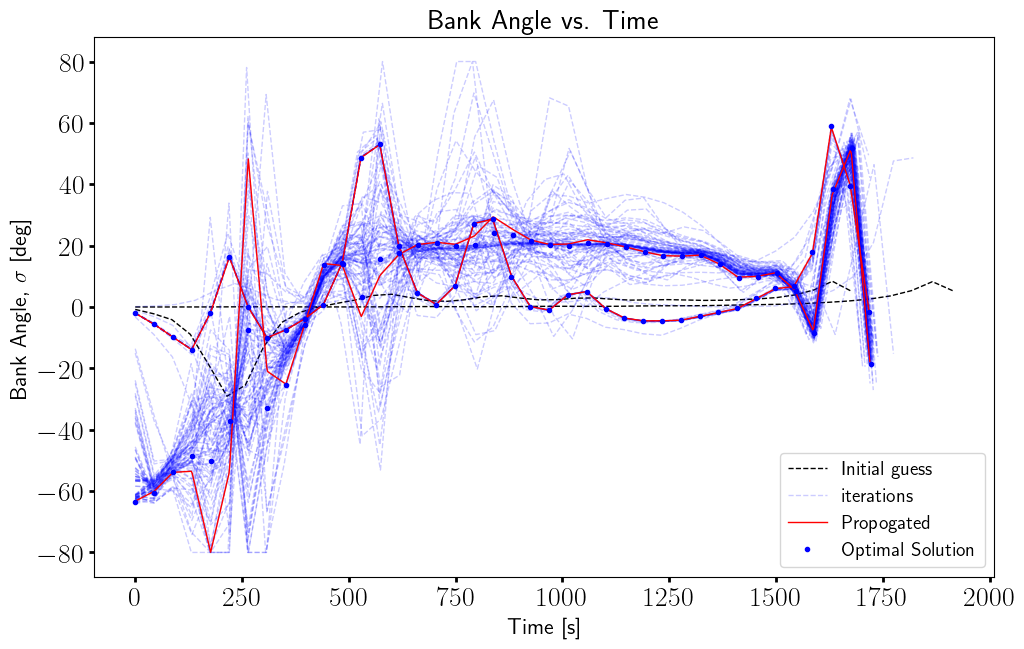

In [13]:
### TO FIX
### ================================================ ###
sind = 0; # STATE INDEX FOR BANK ANGLE 
### ================================================ ###

# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(0,0)] = [0.5,0.5,0.9,0.9];
axs = PLTS1.createGrid(fig,grid = grid);

state_inds = [sind];
state_plot_inds = {sind:(0,0)};
state_names = {sind:'Bank Angle'};

titles = {}; ylabels = {};
titles[(0,0)] = 'Bank Angle vs. Time';
ylabels[(0,0)] = 'Bank Angle, $\sigma$ [deg]';

scenarios = ['scenario1'];
methods = ['autotune']; # methods = ['standard','autotune'];

itrs_all = list(range(1000))[2:]; runs = list(range(1000));
for sind in state_inds:
    aind = state_plot_inds[sind];
    ax = axs[aind];
    PLTS1.setCurrent({'scenarios':scenarios,'methods':methods,'runs':runs})

    params1 = {'label':'Initial guess','x':'t','y':('u',sind),'iters':[1],'legend':sind,};
    params2 = {'label':'iterations','x':'t','y':('u',sind),'iters':itrs_all,'legend':sind};
    params3 = {'label':'Propogated','x':'t_nl','y':('u_nl',sind),'iters':[-1],'legend':sind};
    params4 = {'label':'Optimal Solution','x':'t','y':('u',sind),'iters':[-1],'legend':sind};

    PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
    PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
    PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
    PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4); 
    
    params = {};
    params['title'] = {'text':titles[aind],'fontsize':20}
    params['xlabel'] = {'label':'Time [s]','fontsize':16}
    params['ylabel'] = {'label':ylabels[aind],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    
    PLTS1.addLegend(ax,sind,ins={'fontsize':14,'loc':'best'});

# Fig. 7

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_81220/3776722931.py:25: SyntaxWarning: invalid escape sequence '\p'
  ylabels[3] = 'Heading $\psi$ [deg]';


0
3
4
5


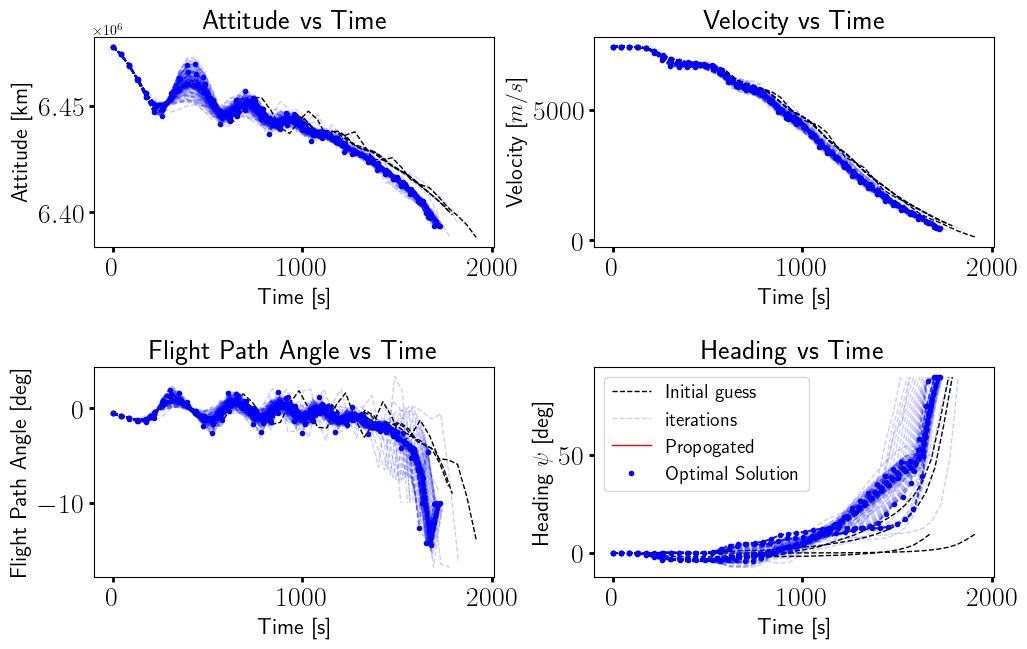

In [29]:
# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(1,1)] = [0.55,0.05,0.4,0.35];
grid[(0,1)] = [0.55,0.6,0.4,0.35];
grid[(1,0)] = [0.05,0.05,0.4,0.35];
grid[(0,0)] = [0.05,0.6,0.4,0.35];
axs = PLTS1.createGrid(fig,grid = grid);

state_inds = [0,3,4,5] # replace with appropriate state indices
state_names = {0:'Altitude',1:'Velocity',2:'Flight Path Angle',3:'Heading'};



state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};


titles = {}; ylabels = {};
titles[2] = 'Flight Path Angle vs Time';
titles[3] = 'Heading vs Time';
titles[0] = 'Attitude vs Time';
titles[1] = 'Velocity vs Time';

ylabels[2] = 'Flight Path Angle [deg]';
ylabels[3] = 'Heading $\psi$ [deg]';
ylabels[0] = 'Attitude [km]';
ylabels[1] = 'Velocity [$m/s$]';

scenarios = ['scenario1'];
methods = ['standard','autotune'];


itrs_all = list(range(1000))[2:]; runs = runs = list(range(1000));
for j,sind in enumerate(state_inds):
    print(sind)
    ax = axs[state_plot_inds[j]];
    PLTS1.setCurrent({'scenarios':scenarios,'methods':methods,'runs':runs})

    params1 = {'label':'Initial guess','x':'t','y':('z',sind),'iters':[1],'legend':sind,};
    params2 = {'label':'iterations','x':'t','y':('z',sind),'iters':itrs_all,'legend':sind};
    params3 = {'label':'Propogated','x':'t_nl','y':('z_nl',sind),'iters':[-1],'legend':sind};
    params4 = {'label':'Optimal Solution','x':'t','y':('z',sind),'iters':[-1],'legend':sind};

    PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
    PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
    PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
    PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4); 
    
    params = {};
    params['title'] = {'text':titles[j],'fontsize':20}
    params['xlabel'] = {'label':'Time [s]','fontsize':16}
    params['ylabel'] = {'label':ylabels[j],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    if j == 3: PLTS1.addLegend(ax,sind,ins={'fontsize':14,'loc':'best'});

In [27]:
temp = data['scenario1']['autotune']['mc_data'][0]['iters'][2]
print(temp['max_q'])

[1.17158944e-01 4.30713910e-01 8.92810626e-01 7.28929441e-01
 4.16881703e-01 6.38917411e-01 3.41497525e-01 2.03893598e-01
 5.66481751e-01 8.60464351e-01 6.11327602e-01 8.58872394e-01
 2.61938147e-01 5.72651812e-02 9.05021880e-01 3.48572771e-01
 4.28307940e-01 6.45418064e-01 8.73664817e-01 5.94550071e-02
 5.63190650e-01 2.65801680e-01 3.16264087e-01 7.30052988e-01
 6.19503565e-01 9.24446488e-01 5.66608476e-01 7.74465664e-01
 2.65261064e-01 1.60573409e-01 8.32542772e-02 8.34466322e-02
 9.41624226e-01 3.27665156e-01 7.17487471e-01 8.70894038e-02
 9.74961962e-01 8.04433053e-01 6.39464024e-01 4.68250399e-01
 6.86014718e-01 5.38717616e-01 1.14498849e-01 9.45550032e-01
 3.56038418e-01 9.17726292e-01 2.01314095e-01 2.00841526e-01
 5.00936662e-01 2.25612337e-01 7.71181758e-01 6.89640541e-01
 2.84154745e-01 2.62324656e-01 8.95210473e-01 2.14374724e-01
 8.12104011e-01 6.50674083e-01 8.22481693e-01 5.94011931e-01
 1.25020717e-01 5.93427250e-02 2.21636103e-01 5.05122001e-01
 1.43561994e-02 4.204393

# Fig.8 heat rate etc. 

5
5
5


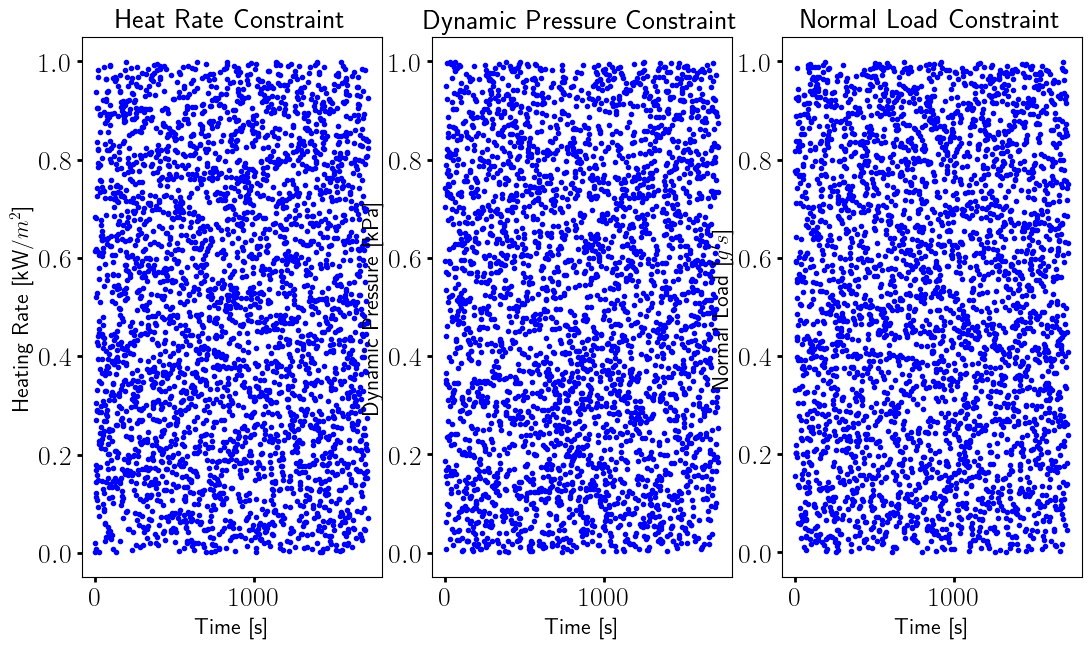

In [31]:
# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(0,0)] = [0.05,0.05,0.3,0.9];
grid[(0,1)] = [0.4,0.05,0.3,0.9];
grid[(0,2)] = [0.75,0.05,0.3,0.9];

axs = PLTS1.createGrid(fig,grid = grid);

tags = ['max_q','max_Q','max_load']
state_names = {0:'Altitude',1:'Velocity',2:'Flight Path Angle',3:'Heading'};



state_plot_inds = {0:(0,0),1:(0,1),2:(0,2)};


titles = {}; ylabels = {};

titles[0] = 'Heat Rate Constraint';
titles[1] = 'Dynamic Pressure Constraint';
titles[2] = 'Normal Load Constraint';

ylabels[0] = 'Heating Rate [kW/$m^2$]';
ylabels[1] = 'Dynamic Pressure [kPa]';
ylabels[2] = 'Normal Load [$g\'s$]';

scenarios = ['scenario1'];
methods = ['standard','autotune'];


itrs_all = list(range(1000))[2:]; runs = runs = list(range(1000));
for j,tag in enumerate(tags):
    print(sind)
    ax = axs[state_plot_inds[j]];
    PLTS1.setCurrent({'scenarios':scenarios,'methods':methods,'runs':runs})

    params1 = {'label':'Initial guess','x':'t_nl','y':tag,'iters':[1],'legend':sind,};
    params2 = {'label':'iterations','x':'t_nl','y':tag,'iters':itrs_all,'legend':sind};
    params3 = {'label':'Propogated','x':'t_nl','y':tag,'iters':[-1],'legend':sind};
    params4 = {'label':'Optimal Solution','x':'t_nl','y':tag,'iters':[-1],'legend':sind};

    # PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
    # PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
    # PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
    PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4); 
    
    params = {};
    params['title'] = {'text':titles[j],'fontsize':20}
    params['xlabel'] = {'label':'Time [s]','fontsize':16}
    params['ylabel'] = {'label':ylabels[j],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    if j == 3: PLTS1.addLegend(ax,sind,ins={'fontsize':14,'loc':'best'});

In [ ]:
# 